In [2]:
import pandas as pd
import json

with open("../data/raw/bioshock_1_reviews.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

df = pd.json_normalize(raw)
df.shape

(26155, 34)

In [3]:
df.columns.tolist()

['recommendationid',
 'language',
 'review',
 'timestamp_created',
 'timestamp_updated',
 'voted_up',
 'votes_up',
 'votes_funny',
 'weighted_vote_score',
 'comment_count',
 'steam_purchase',
 'received_for_free',
 'refunded',
 'written_during_early_access',
 'primarily_steam_deck',
 'app_release_date',
 'reactions',
 'author.steamid',
 'author.personaname',
 'author.persona_status',
 'author.profile_url',
 'author.num_games_owned',
 'author.num_reviews',
 'author.playtime_forever',
 'author.playtime_last_two_weeks',
 'author.playtime_at_review',
 'author.deck_playtime_at_review',
 'author.last_played',
 'author.avatar',
 'hardware.system_ram',
 'hardware.os',
 'hardware.cpu_name',
 'hardware.adapter_description',
 'hardware.vram_size']

In [4]:
df[["review", "voted_up", "timestamp_created", "author.playtime_forever"]].head(10)

,review,voted_up,timestamp_created,author.playtime_forever
0,Lackluster ending in this game. I took way too...,True,1783975687,2318
1,this is a perfect shooter games and i just lov...,True,1783958888,498
2,Favorite game of all time.,True,1783949450,1655
3,[H1]GET THIS GAME[/H1]\ninsane story and gamep...,True,1783912955,552
4,Great Classic. Great Story,True,1783906206,796
5,bio shocked,True,1783902827,483
6,Simple and fun FPS game.,True,1783896773,2598
7,"I mean, just buy it. One of the greatest games...",True,1783895750,588
8,mega kino,True,1783885694,2352
9,I hate Ayn Rand,True,1783883782,297


In [5]:
def load_reviews(filename):
    """Load a raw Steam review JSON and flatten to a DataFrame."""
    with open(f"../data/raw/{filename}", "r", encoding="utf-8") as f:
        return pd.json_normalize(json.load(f))

df_b1 = load_reviews("bioshock_1_reviews.json")
df_b2 = load_reviews("bioshock_2_reviews.json")
df_inf = load_reviews("bioshock_infinite_reviews.json")

for name, frame in [("BioShock 1", df_b1), ("BioShock 2", df_b2), ("Bioshock Infinite", df_inf)]:
    print(f"{name}: {frame.shape}")

BioShock 1: (26155, 34)
BioShock 2: (12008, 34)
Bioshock Infinite: (47232, 34)


In [6]:
for name, frame in [("BioShock 1", df_b1), ("BioShock 2", df_b2), ("Infinite", df_inf)]:
    dupes = frame["recommendationid"].duplicated().sum()
    print(f"{name}: {dupes} duplicate review IDs")

BioShock 1: 0 duplicate review IDs
BioShock 2: 0 duplicate review IDs
Infinite: 0 duplicate review IDs


In [7]:
for frame in (df_b1, df_b2, df_inf):
    frame["review_date"] = pd.to_datetime(frame["timestamp_created"], unit="s")

In [8]:
for name, frame in [("BioShock 1", df_b1), ("BioShock 2", df_b2), ("Infinite", df_inf)]:
    print(f"{name}: {frame['review_date'].min()} → {frame['review_date'].max()}")

BioShock 1: 2016-09-15 22:26:40 → 2026-07-13 20:48:07
BioShock 2: 2016-09-15 23:14:59 → 2026-07-15 15:02:18
Infinite: 2013-04-01 23:54:19 → 2026-07-13 21:48:05


In [9]:
for name, frame in [("BioShock 1", df_b1), ("BioShock 2", df_b2), ("Infinite", df_inf)]:
    non_english = (frame["language"] != "english").sum()
    print(f"{name}: {non_english} non-English rows")
    print(frame["language"].value_counts().head())

BioShock 1: 0 non-English rows
language
english    26155
Name: count, dtype: int64
BioShock 2: 0 non-English rows
language
english    12008
Name: count, dtype: int64
Infinite: 0 non-English rows
language
english    47232
Name: count, dtype: int64


In [10]:
for name, frame in [("BioShock 1", df_b1), ("BioShock 2", df_b2), ("Infinite", df_inf)]:
    pos_share = frame["voted_up"].mean()
    print(f"{name}: {len(frame):,} reviews, {pos_share:.1%} positive")

BioShock 1: 26,155 reviews, 82.0% positive
BioShock 2: 12,008 reviews, 71.0% positive
Infinite: 47,232 reviews, 91.1% positive


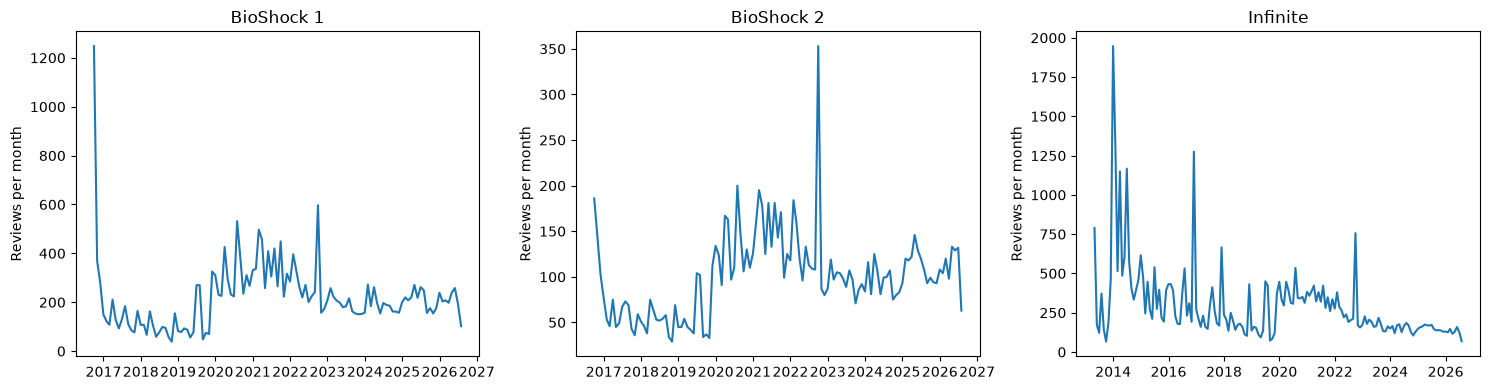

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, (name, frame) in zip(axes, [("BioShock 1", df_b1), ("BioShock 2", df_b2), ("Infinite", df_inf)]):
    monthly = frame.set_index("review_date").resample("ME").size()
    ax.plot(monthly.index, monthly.values)
    ax.set_title(name)
    ax.set_ylabel("Reviews per month")

fig.tight_layout()
plt.show()

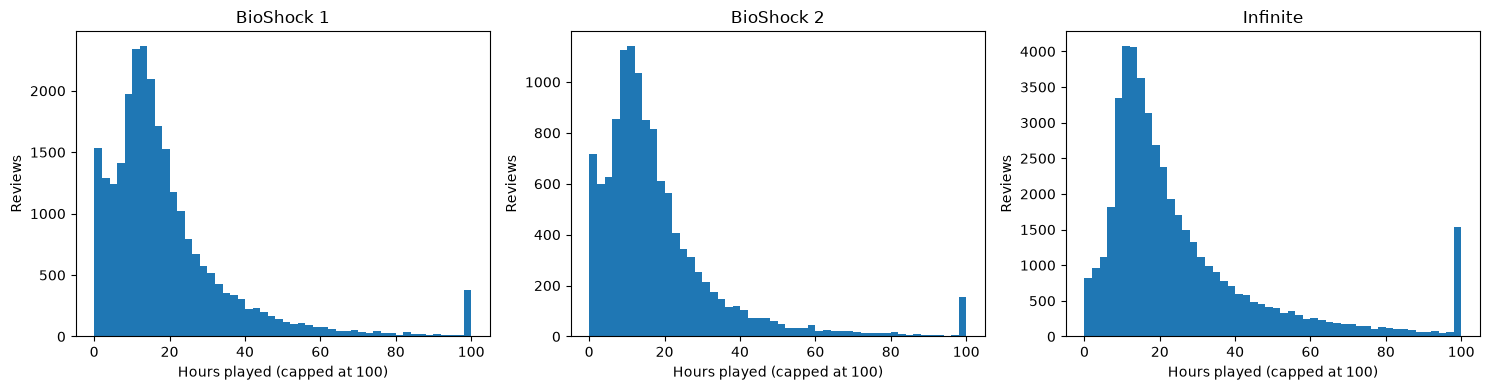

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, frame) in zip(axes, [("BioShock 1", df_b1), ("BioShock 2", df_b2), ("Infinite", df_inf)]):
    hours = frame["author.playtime_forever"] / 60
    ax.hist(hours.clip(upper=100), bins=50)
    ax.set_title(name)
    ax.set_xlabel("Hours played (capped at 100)")
    ax.set_ylabel("Reviews")

fig.tight_layout()
plt.show()

In [13]:
for frame in (df_b1, df_b2, df_inf):
    launch_end = frame["review_date"].min() + pd.DateOffset(years=1)
    frame["era"] = (frame["review_date"] > launch_end).map({False: "launch", True: "later"})

In [14]:
df_b1.to_csv("../data/processed/bioshock_1_clean.csv", index=False)
df_b2.to_csv("../data/processed/bioshock_2_clean.csv", index=False)
df_inf.to_csv("../data/processed/bioshock_infinite_clean.csv", index=False)